In [2]:
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib as mpl


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / "module").exists() and (p / "configs").exists():
            return p
    fallback = Path("/N/u/kmluong/BigRed200/regDL-TCIP")
    if fallback.exists():
        return fallback
    raise FileNotFoundError("Cannot find repo root (folder containing module/ and configs/).")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from visualization.model_loader import load_model_from_paths
from module.training.datasets import load_split_arrays
from module.training.masks import extract_bc_rim_from_y, make_rim_mask_like, make_smooth_phi

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("REPO_ROOT =", REPO_ROOT)
print("DEVICE =", DEVICE)


REPO_ROOT = /geode3/home/u050/kmluong/BigRed200/regDL-TCIP
DEVICE = cpu


In [3]:
def _ensure_sequence_THWC(arr: np.ndarray) -> np.ndarray:
    """Return one sequence as [T,H,W,C]; supports [T,H,W,C] and [T,C,H,W]."""
    if arr.ndim != 4:
        raise ValueError(f"Expected 4D sequence array, got {arr.shape}")

    T, a, b, c = arr.shape
    if c <= 256 and a >= 16 and b >= 16:
        return arr
    if a <= 256 and b >= 16 and c >= 16:
        return np.transpose(arr, (0, 2, 3, 1))
    raise ValueError(f"Cannot infer layout for sequence shape={arr.shape}")


def load_data_array(data_source: str | Path, split: str = "test"):
    """Load data as [N,F,H,W,C]. Accepts split temp dir, 5D .npy, or old WRF 4D sequence .npy."""
    p = Path(data_source)
    if p.is_dir():
        train, val, test = load_split_arrays(p)
        split = split.lower()
        if split == "train":
            arr = train
        elif split == "val":
            if val is None:
                raise ValueError("No val.npy found in this temp dir.")
            arr = val
        elif split == "test":
            arr = test
        else:
            raise ValueError(f"Invalid split: {split}")
        source_kind = f"temp_dir:{split}"
    else:
        if p.suffix != ".npy":
            raise ValueError(f"DATA_SOURCE must be temp dir or .npy file, got: {p}")
        arr = np.load(p, mmap_mode="r")
        source_kind = "npy"

    if arr.ndim == 4:
        arr = _ensure_sequence_THWC(arr)[None, ...]
    if arr.ndim != 5:
        raise ValueError(f"Data must have shape [N,F,H,W,C], got: {arr.shape}")

    return arr, source_kind


def make_window_tensors(arr, n_idx: int, f_idx: int, step_in: int, device: str):
    N, Fseq, H, W, C = arr.shape
    if not (0 <= n_idx < N):
        raise IndexError(f"SAMPLE_N out of range [0, {N - 1}]")
    if not (0 <= f_idx <= Fseq - step_in - 1):
        raise IndexError(
            f"SAMPLE_F out of range [0, {Fseq - step_in - 1}] "
            f"to keep a valid target frame (F={Fseq}, step_in={step_in})"
        )

    x_np = arr[n_idx, f_idx:f_idx + step_in, ...]
    y_np = arr[n_idx, f_idx + step_in, ...]

    x = torch.from_numpy(np.transpose(x_np, (0, 3, 1, 2)).copy()).float().unsqueeze(0).to(device)
    y = torch.from_numpy(np.transpose(y_np, (2, 0, 1)).copy()).float().unsqueeze(0).to(device)
    return x, y


def shift_2d_int(x: torch.Tensor, dy: int, dx: int) -> torch.Tensor:
    """Integer shift for [H,W], [C,H,W], or [B,C,H,W]; zero-padded, same shape."""
    if x.dim() == 2:
        x_ = x.unsqueeze(0).unsqueeze(0)
        squeeze_back = "HW"
    elif x.dim() == 3:
        x_ = x.unsqueeze(0)
        squeeze_back = "CHW"
    elif x.dim() == 4:
        x_ = x
        squeeze_back = "BCHW"
    else:
        raise ValueError(f"Unsupported dim: {x.dim()}")

    _, _, H, W = x_.shape
    pad_top = max(dy, 0)
    pad_bottom = max(-dy, 0)
    pad_left = max(dx, 0)
    pad_right = max(-dx, 0)

    x_pad = F.pad(x_, (pad_left, pad_right, pad_top, pad_bottom), mode="constant", value=0.0)
    y0 = pad_top - dy
    x0 = pad_left - dx
    out = x_pad[:, :, y0:y0 + H, x0:x0 + W]

    if squeeze_back == "HW":
        return out[0, 0]
    if squeeze_back == "CHW":
        return out[0]
    return out


def auto_align_pred_by_ch0(
    y_true: torch.Tensor,
    y_pred: torch.Tensor,
    ref_channel: int = 0,
    crop_size: int = 80,
    win_size: int = 30,
    max_shift: int = 20,
):
    """Auto-align y_pred to y_true by brute-force shift search on one channel."""
    if y_true.dim() != 4 or y_pred.dim() != 4:
        raise ValueError("Expect y_true/y_pred as [B,C,H,W]")
    if y_true.shape[0] != 1 or y_pred.shape[0] != 1:
        raise ValueError("Auto-align helper assumes B=1")

    _, _, H, W = y_true.shape
    cy, cx = H // 2, W // 2
    half = crop_size // 2
    y1, y2 = max(cy - half, 0), min(cy + half, H)
    x1, x2 = max(cx - half, 0), min(cx + half, W)

    t = y_true[0, ref_channel, y1:y2, x1:x2]
    p = y_pred[0, ref_channel, y1:y2, x1:x2]

    cropH, cropW = t.shape
    wy, wx = cropH // 2, cropW // 2
    halfw = win_size // 2
    ty1, ty2 = wy - halfw, wy + halfw
    tx1, tx2 = wx - halfw, wx + halfw
    if ty1 < 0 or tx1 < 0 or ty2 > cropH or tx2 > cropW:
        raise ValueError("Template window goes out of crop; check crop_size/win_size.")

    template = t[ty1:ty2, tx1:tx2]
    best_loss = None
    best_dy, best_dx = 0, 0
    for dy in range(-max_shift, max_shift + 1):
        for dx in range(-max_shift, max_shift + 1):
            p_shift = shift_2d_int(p, dy=dy, dx=dx)
            cand = p_shift[ty1:ty2, tx1:tx2]
            loss = torch.mean(torch.abs(cand - template))
            if best_loss is None or loss < best_loss:
                best_loss = loss
                best_dy, best_dx = dy, dx

    return shift_2d_int(y_pred, dy=best_dy, dx=best_dx), best_dy, best_dx


def center_crop_2d(a: torch.Tensor, crop: int = 80) -> torch.Tensor:
    H, W = a.shape
    cy, cx = H // 2, W // 2
    half = crop // 2
    y1, y2 = max(cy - half, 0), min(cy + half, H)
    x1, x2 = max(cx - half, 0), min(cx + half, W)
    return a[y1:y2, x1:x2]


In [4]:
def run_inference_one_window(model, cfg, x, y_true, rim: int = 3):
    """Run one-window inference and match training-time scaler/BC behavior."""
    model.eval()
    arch = str(cfg.get("architecture", "")).lower()
    use_bc = arch in {"afno_v1"}

    with torch.no_grad():
        x_in = x
        y_in = y_true

        if getattr(model, "x_scaler", None) is not None:
            x_in = model.x_scaler.norm(x_in)
        if getattr(model, "y_scaler", None) is not None:
            y_in = model.y_scaler.norm(y_in)

        if use_bc:
            b_fill = extract_bc_rim_from_y(y_in, rim=rim)
            bc_mask = make_rim_mask_like(y_in, rim=rim)
            bc_in = torch.cat([b_fill, bc_mask], dim=1)
            y_free = model(x_in, bc_in)

            phi = make_smooth_phi(
                H=y_in.shape[-2],
                W=y_in.shape[-1],
                rim=rim,
                device=y_in.device,
                dtype=y_in.dtype,
            )
            y_pred_norm = phi * y_free + (1.0 - phi) * b_fill
        else:
            y_pred_norm = model(x_in)

        if getattr(model, "y_scaler", None) is not None:
            y_pred = model.y_scaler.denorm(y_pred_norm)
        else:
            y_pred = y_pred_norm

    return y_pred, y_true


def _build_regular_latlon_grid(H: int, W: int, center_lat: float, center_lon: float, sep_deg: float):
    """Regular lat/lon grid centered at center_lat/center_lon with constant degree spacing."""
    r0 = (H - 1) / 2.0
    c0 = (W - 1) / 2.0
    lat_1d = center_lat + (np.arange(H, dtype=np.float64) - r0) * sep_deg
    lon_1d = center_lon + (np.arange(W, dtype=np.float64) - c0) * sep_deg
    lon2d, lat2d = np.meshgrid(lon_1d, lat_1d)
    return lon2d, lat2d


def _extent_from_lonlat(lon2d: np.ndarray, lat2d: np.ndarray):
    """imshow extent = (xmin, xmax, ymin, ymax) in degrees."""
    return (
        float(np.nanmin(lon2d)),
        float(np.nanmax(lon2d)),
        float(np.nanmin(lat2d)),
        float(np.nanmax(lat2d)),
    )


def _add_quiver(ax, lonQ, latQ, u, v, *, step: int, scale: float | None):
    uQ = u[::step, ::step]
    vQ = v[::step, ::step]
    ax.quiver(
        lonQ,
        latQ,
        uQ,
        vQ,
        color="black",
        alpha=0.72,
        width=0.0022,
        scale=scale,
        pivot="middle",
    )


def plot_wrf_sample_comparison(
    *,
    data_source: str | Path,
    model_config_path_bc: str | Path,
    model_checkpoint_path_bc: str | Path,
    model_config_path_nbc: str | Path,
    model_checkpoint_path_nbc: str | Path,
    split: str = "test",
    sample_n: int = 0,
    sample_f: int = 350,
    channel: int = 0,
    device: str = DEVICE,
    rim: int = 3,
    wrf_center_lat: float = 20.0498,
    wrf_center_lon: float = 0.0,
    wrf_sep_deg: float = 0.173,
    quiver_step: int = 6,
    quiver_scale: float | None = 42,
    show_quiver: bool = True,
    u_ch: int = 0,
    v_ch: int = 1,
    field_cmap: str = "viridis",
    diff_cmap: str = "coolwarm",
    save_path: str | Path | None = "visualization_wrf_map.png",
):
    arr, source_kind = load_data_array(data_source, split=split)

    model_bc, meta_bc = load_model_from_paths(
        config_path=model_config_path_bc,
        checkpoint_path=model_checkpoint_path_bc,
        map_location=device,
        strict=True,
        eval_mode=True,
    )
    model_bc = model_bc.to(device)

    model_nbc, meta_nbc = load_model_from_paths(
        config_path=model_config_path_nbc,
        checkpoint_path=model_checkpoint_path_nbc,
        map_location=device,
        strict=True,
        eval_mode=True,
    )
    model_nbc = model_nbc.to(device)

    step_in_bc = int(meta_bc["config"]["num_times"])
    step_in_nbc = int(meta_nbc["config"]["num_times"])
    step_in = min(step_in_bc, step_in_nbc)

    x, y_true = make_window_tensors(arr, sample_n, sample_f, step_in=step_in, device=device)
    if x.shape[1] < 3:
        raise ValueError("WRF comparison plot expects at least 3 input frames")
    if channel < 0 or channel >= x.shape[2]:
        raise ValueError(f"channel out of range: channel={channel}, C={x.shape[2]}")
    if show_quiver and (u_ch >= x.shape[2] or v_ch >= x.shape[2]):
        raise ValueError(f"u_ch/v_ch out of range for C={x.shape[2]}")

    _, _, _, H, W = x.shape
    lon2d_wrf, lat2d_wrf = _build_regular_latlon_grid(
        H=H,
        W=W,
        center_lat=wrf_center_lat,
        center_lon=wrf_center_lon,
        sep_deg=wrf_sep_deg,
    )
    extent_wrf = _extent_from_lonlat(lon2d_wrf, lat2d_wrf)
    lonQ_wrf = lon2d_wrf[::quiver_step, ::quiver_step]
    latQ_wrf = lat2d_wrf[::quiver_step, ::quiver_step]

    y_pred_bc, y_ref = run_inference_one_window(model_bc, meta_bc["config"], x, y_true, rim=rim)
    y_pred_nbc, _ = run_inference_one_window(model_nbc, meta_nbc["config"], x, y_true, rim=rim)

    c = int(channel)
    in_maps = [x[0, t, c].detach().cpu().numpy() for t in range(3)]
    truth_map = y_ref[0, c].detach().cpu().numpy()
    pred_bc_map = y_pred_bc[0, c].detach().cpu().numpy()
    pred_nbc_map = y_pred_nbc[0, c].detach().cpu().numpy()

    d_truth_bc = truth_map - pred_bc_map
    d_truth_nbc = truth_map - pred_nbc_map
    d_bc_nbc = pred_bc_map - pred_nbc_map

    field_maps = in_maps + [pred_bc_map, pred_nbc_map, truth_map]
    vmin = min(float(np.nanmin(m)) for m in field_maps)
    vmax = max(float(np.nanmax(m)) for m in field_maps)

    diff_maps = [d_truth_bc, d_truth_nbc, d_bc_nbc]
    dmax = max(float(np.nanmax(np.abs(m))) for m in diff_maps)
    d_vmin, d_vmax = -dmax, dmax

    print("source_kind =", source_kind)
    print("data shape =", arr.shape, "[N,F,H,W,C]")
    print("BC architecture =", meta_bc["config"]["architecture"])
    print("NO-BC architecture =", meta_nbc["config"]["architecture"])
    print("step_in =", step_in)
    print(f"sample_n={sample_n}, sample_f={sample_f}, target_f={sample_f + step_in}")
    print("extent_wrf =", extent_wrf)

    fig, axes = plt.subplots(3, 3, figsize=(14, 14), sharex=False, sharey=False)

    # Row 1: inputs
    for j in range(3):
        im_field = axes[0, j].imshow(
            in_maps[j],
            origin="lower",
            extent=extent_wrf,
            vmin=vmin,
            vmax=vmax,
            cmap=field_cmap,
            aspect="auto",
        )
        if show_quiver:
            u = x[0, j, u_ch].detach().cpu().numpy()
            v = x[0, j, v_ch].detach().cpu().numpy()
            _add_quiver(axes[0, j], lonQ_wrf, latQ_wrf, u, v, step=quiver_step, scale=quiver_scale)

    # Row 2: predictions + truth
    axes[1, 0].imshow(pred_nbc_map, origin="lower", extent=extent_wrf,
                      vmin=vmin, vmax=vmax, cmap=field_cmap, aspect="auto")
    axes[1, 1].imshow(pred_bc_map, origin="lower", extent=extent_wrf,
                      vmin=vmin, vmax=vmax, cmap=field_cmap, aspect="auto")
    axes[1, 2].imshow(truth_map, origin="lower", extent=extent_wrf,
                      vmin=vmin, vmax=vmax, cmap=field_cmap, aspect="auto")

    if show_quiver:
        for ax, tensor in [
            (axes[1, 0], y_pred_nbc),
            (axes[1, 1], y_pred_bc),
            (axes[1, 2], y_ref),
        ]:
            u = tensor[0, u_ch].detach().cpu().numpy()
            v = tensor[0, v_ch].detach().cpu().numpy()
            _add_quiver(ax, lonQ_wrf, latQ_wrf, u, v, step=quiver_step, scale=quiver_scale)

    # Row 3: diagnostics
    im_diff = axes[2, 0].imshow(d_truth_nbc, origin="lower", extent=extent_wrf,
                                vmin=d_vmin, vmax=d_vmax, cmap=diff_cmap, aspect="auto")
    axes[2, 1].imshow(d_truth_bc, origin="lower", extent=extent_wrf,
                      vmin=d_vmin, vmax=d_vmax, cmap=diff_cmap, aspect="auto")
    axes[2, 2].imshow(d_bc_nbc, origin="lower", extent=extent_wrf,
                      vmin=d_vmin, vmax=d_vmax, cmap=diff_cmap, aspect="auto")

    titles = [
        ["Input frame 1", "Input frame 2", "Input frame 3"],
        ["Pred NO-BC", "Pred BC", "Truth"],
        ["Truth-NOBC", "Truth-BC", "BC-NOBC"],
    ]
    for i in range(3):
        for j in range(3):
            axes[i, j].set_title(titles[i][j])
            axes[i, j].tick_params(labelsize=8)
            axes[i, j].set_xlabel("Longitude")
            axes[i, j].set_ylabel("Latitude")

    cbar_ax_top = fig.add_axes([0.15, 0.92, 0.7, 0.02])
    cbar_top = fig.colorbar(im_field, cax=cbar_ax_top, orientation="horizontal")
    cbar_top.set_label(f"Channel {c}")
    cbar_top.ax.xaxis.set_label_position("top")

    cbar_ax_bottom = fig.add_axes([0.15, 0.07, 0.7, 0.02])
    cbar_bottom = fig.colorbar(im_diff, cax=cbar_ax_bottom, orientation="horizontal")
    cbar_bottom.set_label("Difference")

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    y_true_cpu = y_ref.detach().cpu()
    y_bc_cpu = y_pred_bc.detach().cpu()
    y_nbc_cpu = y_pred_nbc.detach().cpu()
    C = y_true_cpu.shape[1]
    print(f"{'Channel':>7} | {'True min':>10} {'True max':>10} | {'BC min':>10} {'BC max':>10} | {'NOBC min':>10} {'NOBC max':>10}")
    print("-" * 91)
    for ch in range(C):
        true_min = y_true_cpu[0, ch].min().item()
        true_max = y_true_cpu[0, ch].max().item()
        bc_min = y_bc_cpu[0, ch].min().item()
        bc_max = y_bc_cpu[0, ch].max().item()
        nbc_min = y_nbc_cpu[0, ch].min().item()
        nbc_max = y_nbc_cpu[0, ch].max().item()
        print(f"{ch:7d} | {true_min:10.4f} {true_max:10.4f} | {bc_min:10.4f} {bc_max:10.4f} | {nbc_min:10.4f} {nbc_max:10.4f}")


source_kind = temp_dir:test
data shape = (1, 480, 100, 100, 12) [N,F,H,W,C]
BC architecture = afno_v1
NO-BC architecture = afno_no_bc
step_in = 3
sample_n=0, sample_f=350, target_f=353
extent_wrf = (-8.5635, 8.5635, 11.486300000000002, 28.613300000000002)


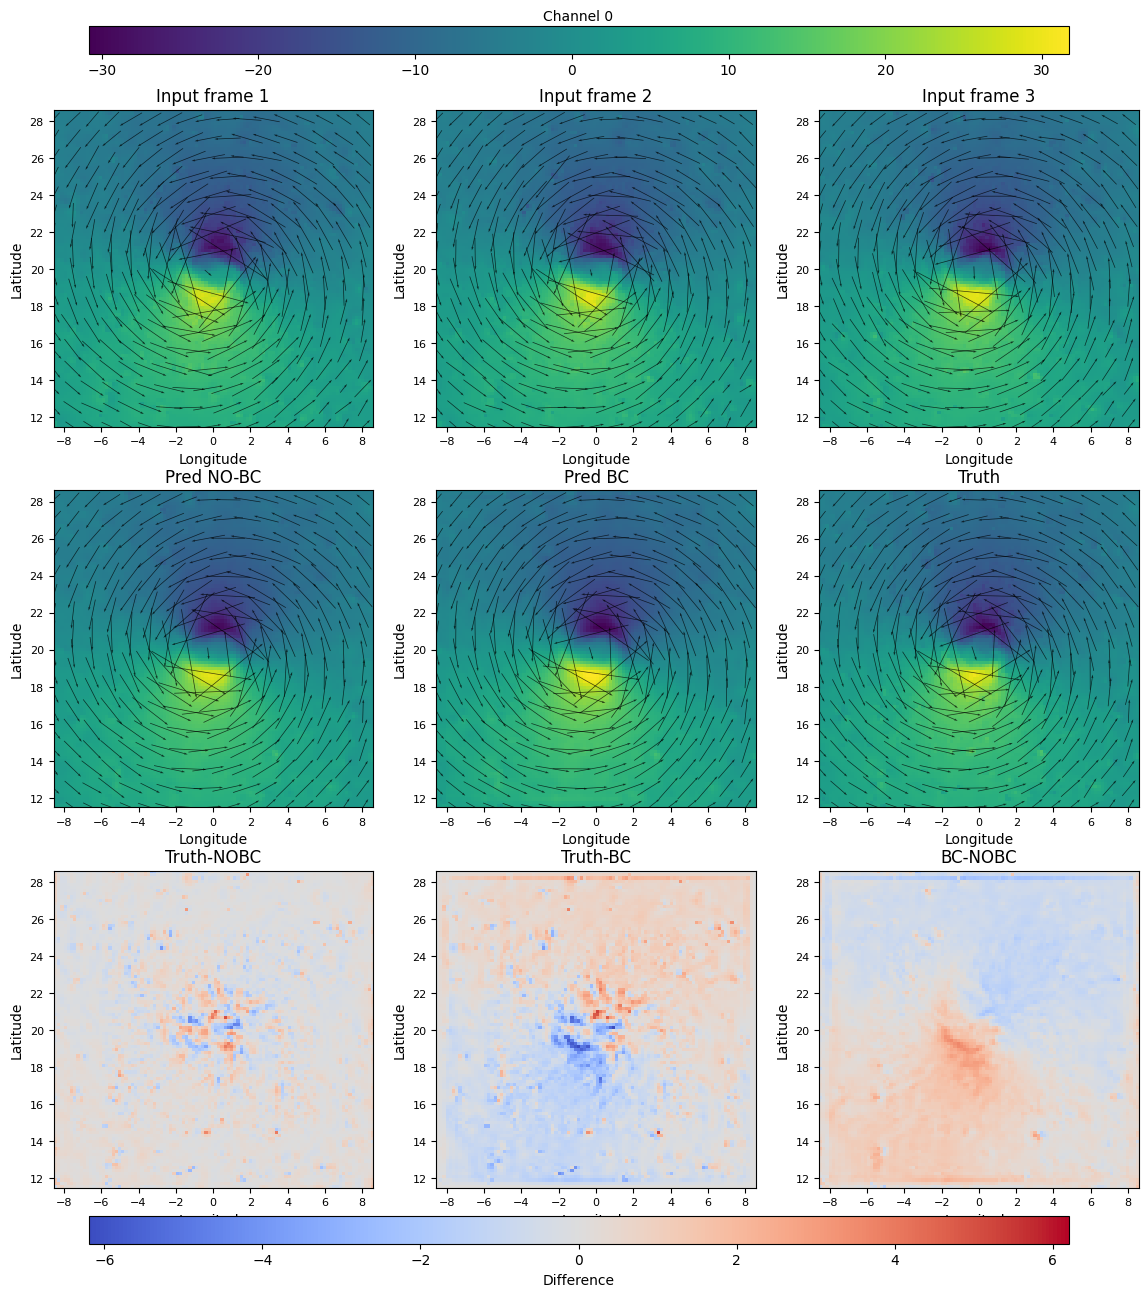

Channel |   True min   True max |     BC min     BC max |   NOBC min   NOBC max
-------------------------------------------------------------------------------------------
      0 |   -30.4702    30.4131 |   -30.8428    31.6903 |   -29.7870    29.4752
      1 |   -28.4198    29.5120 |   -29.3921    30.0674 |   -28.2952    28.7993
      2 |     0.0000     0.0000 |    -0.0000     0.0000 |    -0.0000     0.0000
      3 |     0.0000     0.0000 |    -0.1037     0.0381 |    -0.0235     0.0205
      4 |   -34.7186    34.5360 |   -34.8987    35.7272 |   -32.7141    33.3778
      5 |   -29.5320    30.0764 |   -31.4686    30.4054 |   -28.4941    29.7255
      6 |   -37.6222    35.4651 |   -38.3129    35.7052 |   -35.2082    33.6034
      7 |   -36.2538    39.3166 |   -38.0015    39.5006 |   -35.0187    37.4120
      8 |    64.4340    85.6741 |    66.2529    89.8026 |    65.8858    84.6054
      9 |     0.0008     0.0059 |     0.0012     0.0064 |     0.0009     0.0061
     10 | 56082.2344 57066.5

In [6]:
# ===== WRF 3x3 comparison plot =====
DS = "IDEALIZED"
DATA_SOURCE = f"/N/slate/kmluong/regDL-TCIP/{DS}/tmp"

MODEL_CONFIG_PATH_BC = f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/AFNO-TCP-BC.json"
MODEL_CHECKPOINT_PATH_BC = f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/trained-AFNO-TCP-BC.pt"

MODEL_CONFIG_PATH_NBC = f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/AFNO-TCP-NO-BC.json"
MODEL_CHECKPOINT_PATH_NBC = f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/trained-AFNO-TCP-NO-BC.pt"

plot_wrf_sample_comparison(
    data_source=DATA_SOURCE,
    model_config_path_bc=MODEL_CONFIG_PATH_BC,
    model_checkpoint_path_bc=MODEL_CHECKPOINT_PATH_BC,
    model_config_path_nbc=MODEL_CONFIG_PATH_NBC,
    model_checkpoint_path_nbc=MODEL_CHECKPOINT_PATH_NBC,
    split="test",
    sample_n=0,
    sample_f=350,
    channel=0,
    device=DEVICE,
    rim=3,
    wrf_center_lat=20.0498,
    wrf_center_lon=0.0,
    wrf_sep_deg=0.173,
    quiver_step=6,
    quiver_scale=100,
    show_quiver=True,
    save_path="visualization_wrf_map.png",
)
